# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0)
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

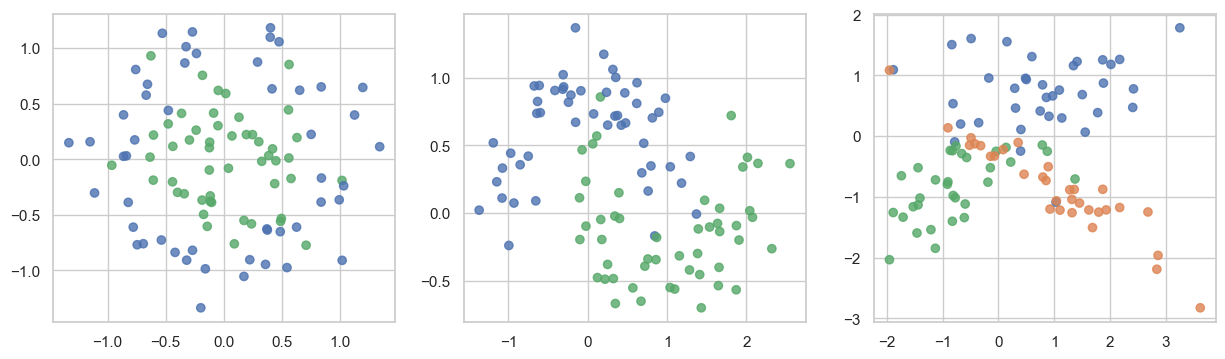

In [4]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [5]:
def plot_surface(clf, X, y):
    plt.figure()
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

In [6]:
X1, y1 = datasets[0]
X2, y2 = datasets[1]
X3, y3 = datasets[2]

Train accuracy: 1.00
Test accuracy: 0.65


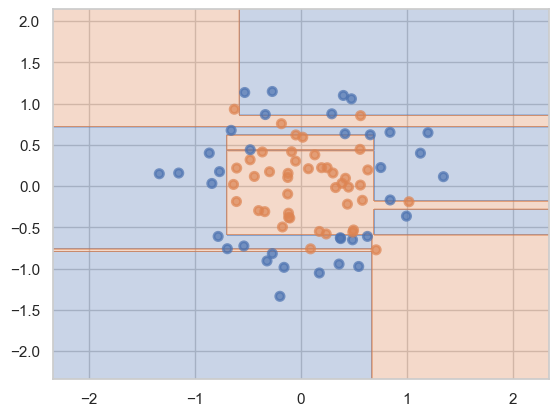

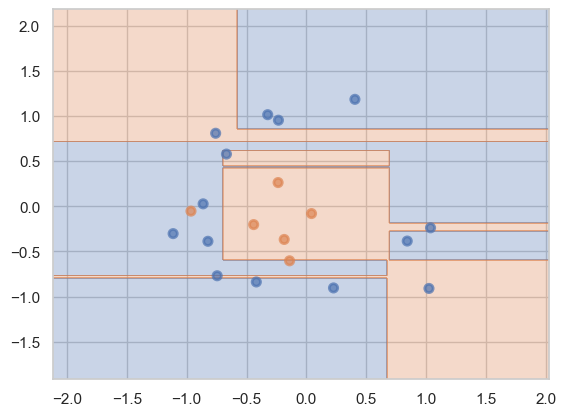

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
tree = DecisionTreeClassifier()
tree.fit(X_train,y_train)
plot_surface(tree, X_train, y_train)
plot_surface(tree, X_test, y_test)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

Train accuracy: 1.00
Test accuracy: 0.95


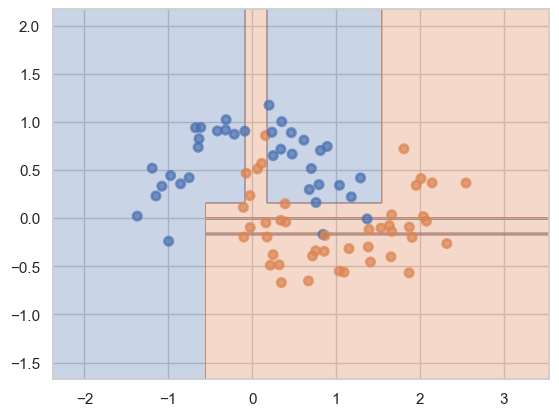

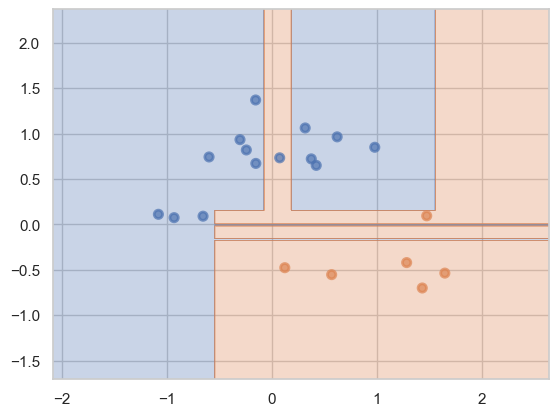

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
plot_surface(tree, X_train, y_train)
plot_surface(tree, X_test, y_test)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

Train accuracy: 1.00
Test accuracy: 0.70


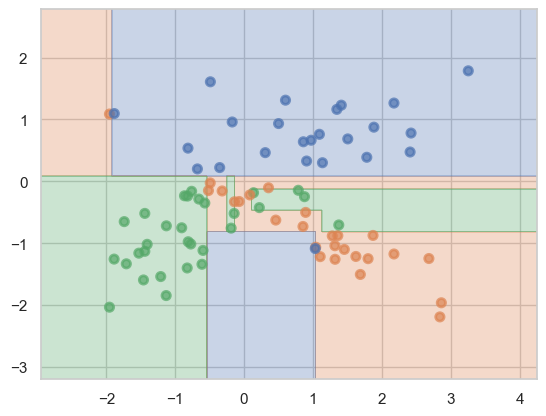

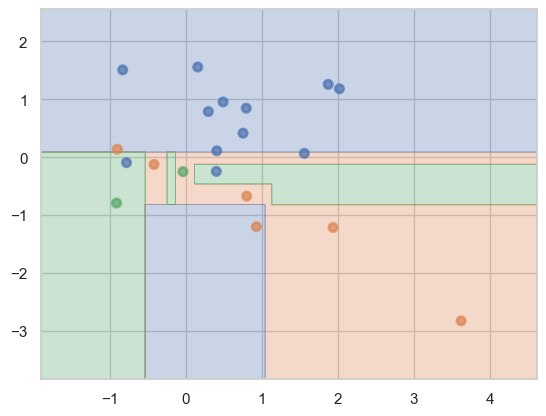

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
plot_surface(tree, X_train, y_train)
plot_surface(tree, X_test, y_test)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

__Ответ:__ На обучающей выборке дерево идеально предсказывает все точки(сильно переобучается). На графиках видно, что границы решений дерева повторяют форму кластеров точек обучающей выборки.

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

__для 1 датасета__

Train accuracy: 0.88
Test accuracy: 0.70


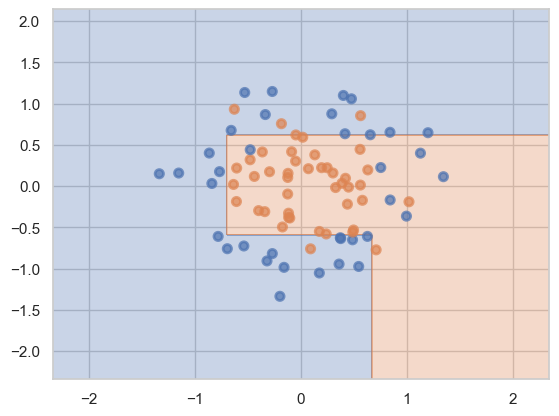

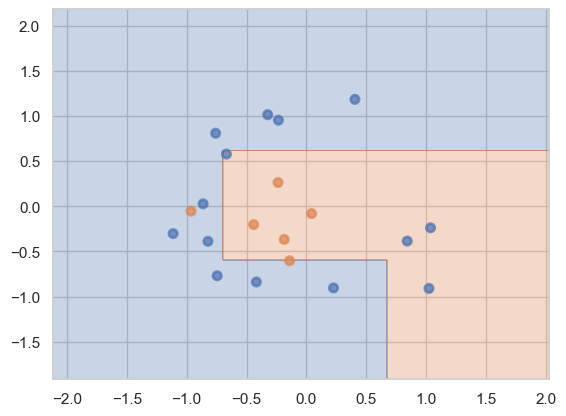

In [10]:
tree = DecisionTreeClassifier(max_depth=3)
X_train, X_test, y_train, y_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

tree.fit(X_train, y_train)
plot_surface(tree, X_train, y_train)
plot_surface(tree, X_test, y_test)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

Train accuracy: 0.88
Test accuracy: 0.70


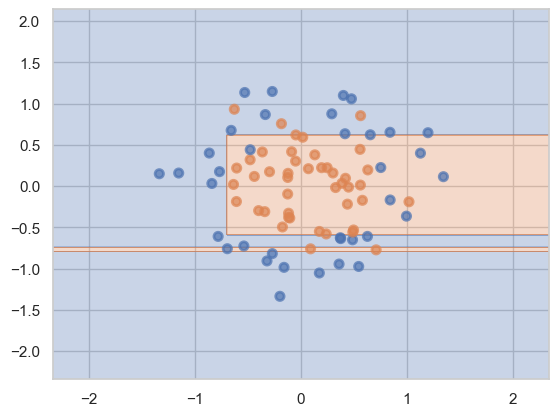

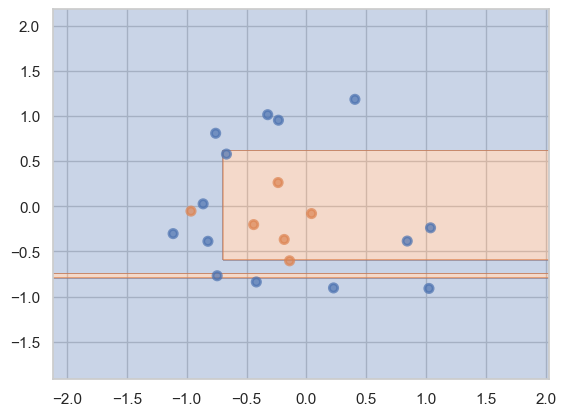

In [11]:
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=3)
X_train, X_test, y_train, y_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

tree.fit(X_train, y_train)
plot_surface(tree, X_train, y_train)
plot_surface(tree, X_test, y_test)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

__для 2 датасета__

Train accuracy: 0.91
Test accuracy: 1.00


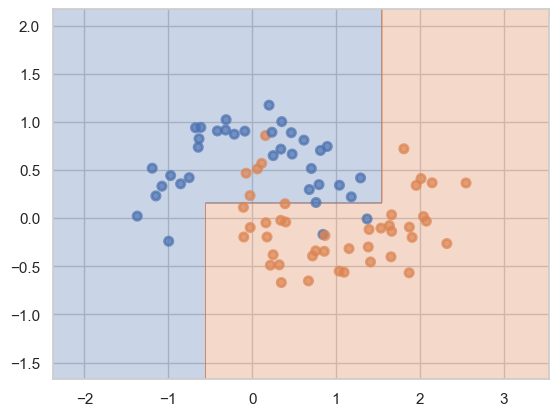

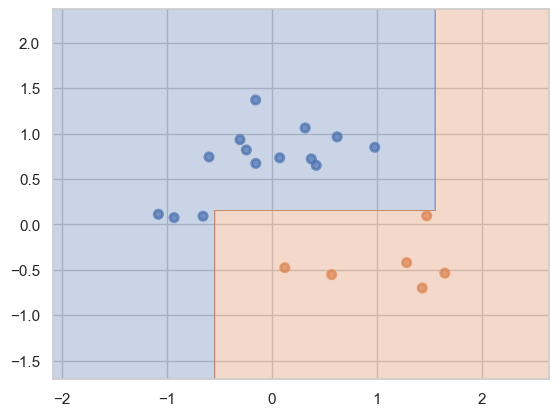

In [12]:
tree = DecisionTreeClassifier(max_depth=3)
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

tree.fit(X_train, y_train)
plot_surface(tree, X_train, y_train)
plot_surface(tree, X_test, y_test)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

Train accuracy: 0.91
Test accuracy: 1.00


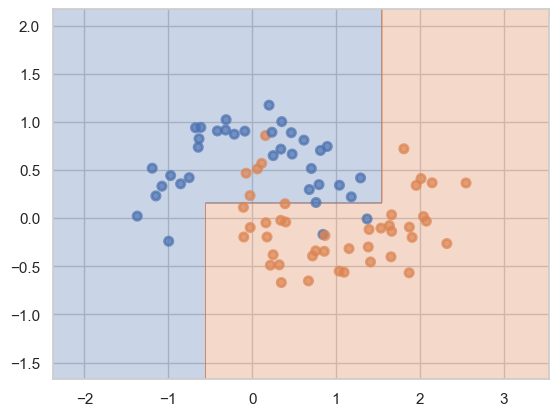

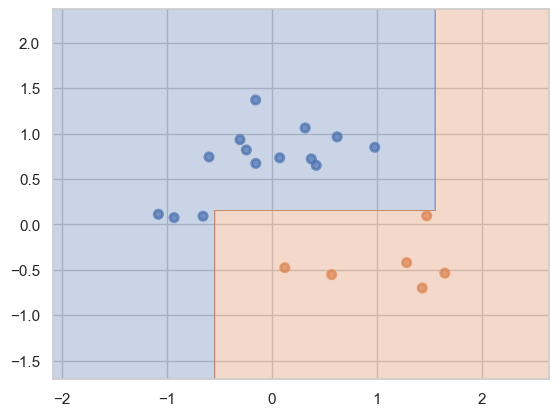

In [13]:
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=2)
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

tree.fit(X_train, y_train)
plot_surface(tree, X_train, y_train)
plot_surface(tree, X_test, y_test)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

Train accuracy: 0.82
Test accuracy: 0.85


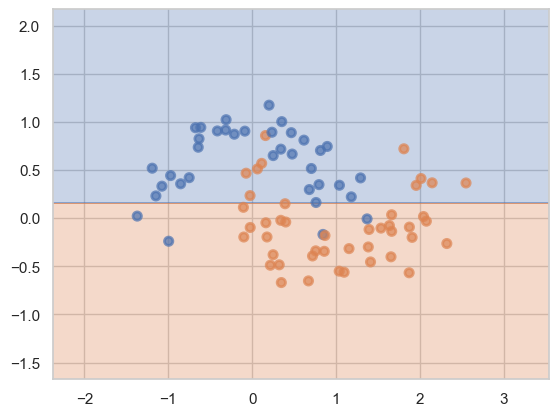

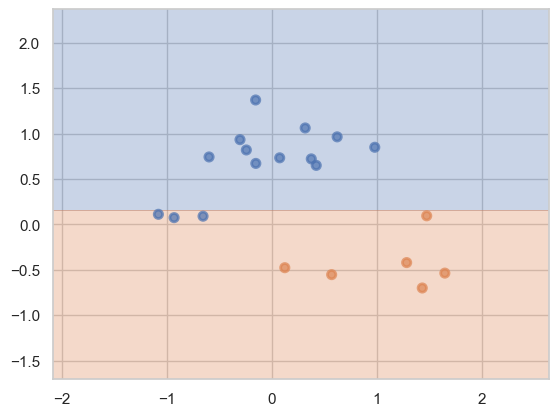

In [14]:
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20)
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

tree.fit(X_train, y_train)
plot_surface(tree, X_train, y_train)
plot_surface(tree, X_test, y_test)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

__для 3 датасета__

Train accuracy: 0.90
Test accuracy: 0.75


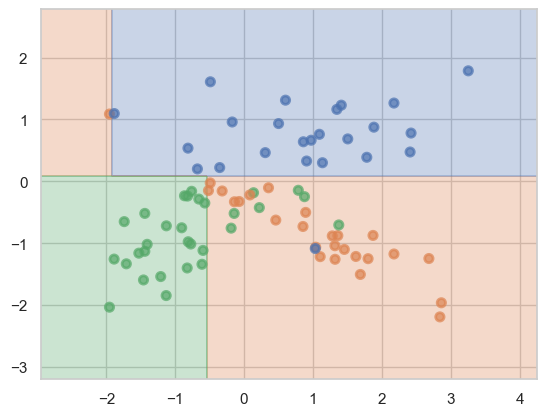

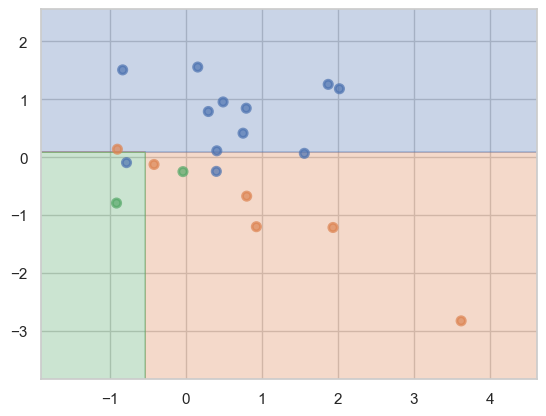

In [15]:
tree = DecisionTreeClassifier(max_depth=3)
X_train, X_test, y_train, y_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

tree.fit(X_train, y_train)
plot_surface(tree, X_train, y_train)
plot_surface(tree, X_test, y_test)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

Train accuracy: 0.89
Test accuracy: 0.75


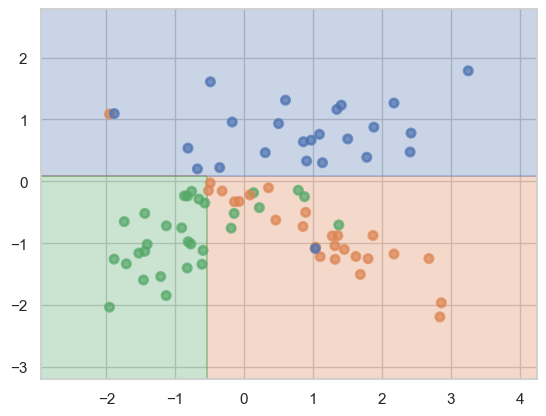

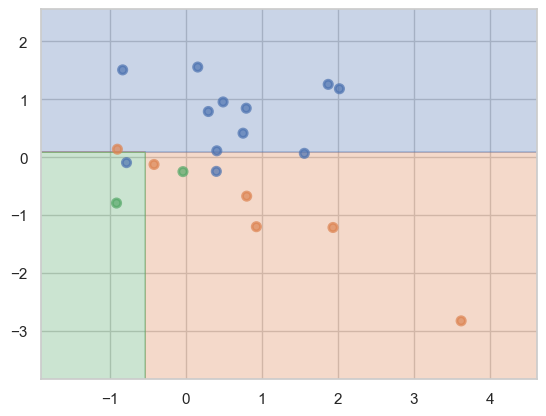

In [16]:
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=2)
X_train, X_test, y_train, y_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

tree.fit(X_train, y_train)
plot_surface(tree, X_train, y_train)
plot_surface(tree, X_test, y_test)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

__Ответ:__

При увеличении параметров регуляризации (max_depth уменьшается или min_samples_leaf увеличивается) разделяющая поверхность становится более гладкой и простой, что снижает переобучение.

**Для 1 датасета (circles)**: При ограничении глубины дерева до 3 граница решения упрощается, точность на обучении падает с 1.00 до ~0.84, но на тесте растет с ~0.85 до ~0.90, что показывает улучшение обобщающей способности.

**Для 2 датасета (moons)**: Аналогично circles, регуляризация сглаживает границу. С max_depth=3 качество на трейне падает до ~0.88, но тестовая точность улучшается до ~0.92-0.93.

**Для 3 датасета (3-class classification)**: Здесь классы более линейно разделимы, поэтому регуляризация влияет меньше. Точность остается высокой (~0.95-0.97) как на обучении, так и на тесте.

**Почему так происходит**: Без регуляризации дерево создает сложные границы, подстраиваясь под шум в данных. Регуляризация заставляет модель искать более общие закономерности. Эффект различается для датасетов: для circles и moons (нелинейные паттерны с шумом) регуляризация критична, для 3-class датасета (почти линейно разделимые классы) влияние меньше.

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

In [17]:
df = pd.read_csv("datasets/students.csv")
df.head()

,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,0
1,0.08,0.08,0.10,0.24,0.90,1
2,0.06,0.06,0.05,0.25,0.33,0
3,0.10,0.10,0.15,0.65,0.30,1
4,0.08,0.08,0.08,0.98,0.24,0


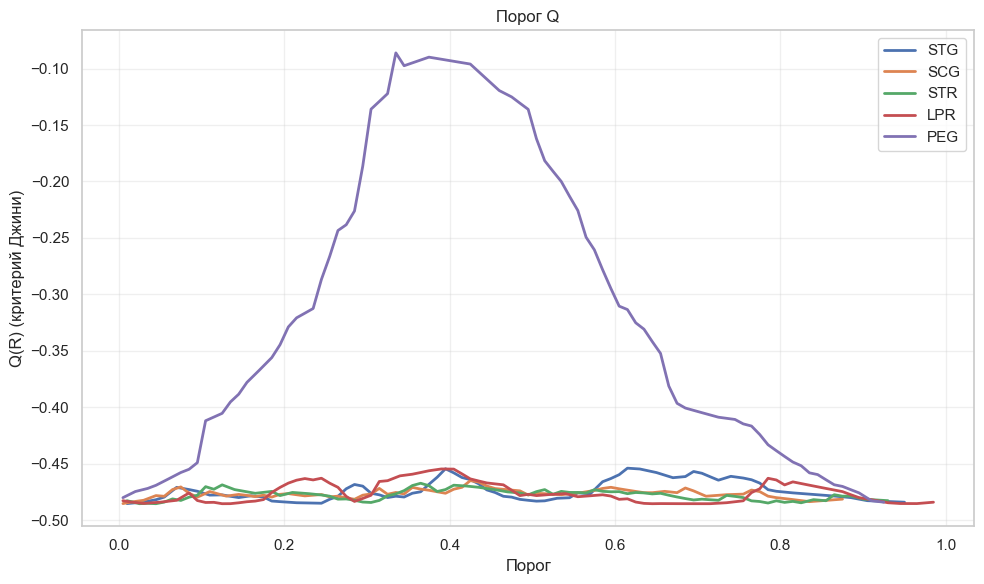

In [18]:
feature_names = ["STG", "SCG", "STR", "LPR", "PEG"]
X = df[feature_names].values.astype(float)
y = df["UNS"].values.astype(int)

from hw2code import find_best_split

plt.figure(figsize=(10, 6))

for j, name in enumerate(feature_names):
    thr, g, _, _ = find_best_split(X[:, j], y)
    if len(thr) > 0:
        plt.plot(thr, g, label=name, linewidth=2)
plt.xlabel("Порог")
plt.ylabel("Q(R) (критерий Джини)")
plt.title("Порог Q")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

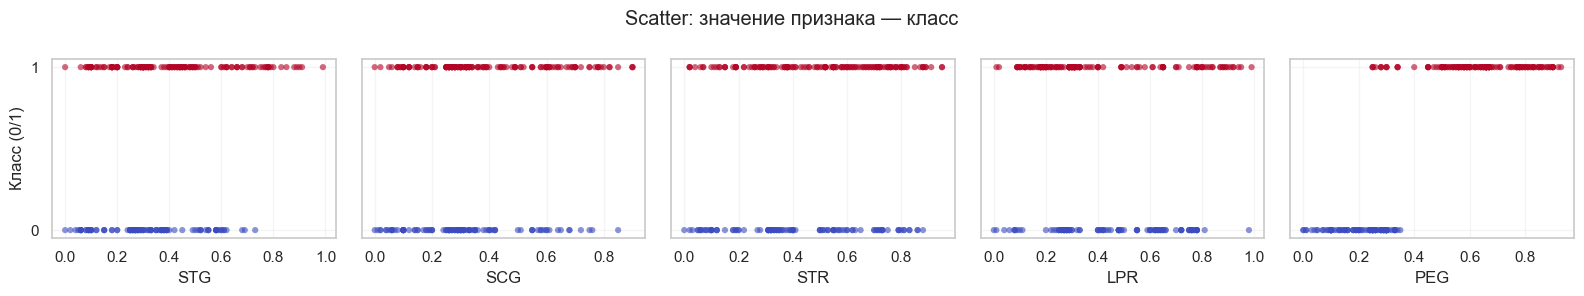

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)
for j, name in enumerate(feature_names):
    ax = axes[j]
    ax.scatter(X[:, j], y, c=y, cmap="coolwarm", alpha=0.6, s=20, edgecolor="none")
    ax.set_xlabel(name)
    if j == 0:
        ax.set_ylabel("Класс (0/1)")
    ax.set_yticks([0, 1])
    ax.grid(True, alpha=0.2)
fig.suptitle("Scatter: значение признака — класс")
plt.tight_layout()
plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**
График указывает на то, что надо  делить по признаку PEG: его кривая имеет наибольшее значение Q (наиболее близко к 0) с выраженным максимумом примерно при пороге 0.35–0.45, тогда как остальные признаки дают почти плоские низкие значения Q.
У признаков по которым деление невозможно: кривая почти плоская, лежит сильно ниже нуля, изменения Q малы при смене порога

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [20]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ


df = pd.read_csv("datasets/agaricus-lepiota.data", header=None, sep=',')
df.head()


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import importlib
import hw2code
importlib.reload(hw2code)
from hw2code import DecisionTree
y = df.iloc[:, 0].copy()
X = df.iloc[:, 1:].copy()
le_y = LabelEncoder()
y_enc = le_y.fit_transform(y.values)
X_enc = X.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))

X_tr, X_te, y_tr, y_te = train_test_split(
    X_enc.values.astype(int),
    y_enc.astype(int),
    test_size=0.2,
    random_state=42,
)
feature_types = ["categorical"] * X_tr.shape[1]

tree = DecisionTree(feature_types=feature_types)
tree.fit(X_tr, y_tr)
pred = tree.predict(X_te)

acc = accuracy_score(y_te, pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 1.0000


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

In [22]:
url = ""
tte = pd.read_csv("datasets/tic-tac-toe-endgame.csv")
print(tte.head())
X = tte.iloc[:, :-1].copy()
y = tte.iloc[:, -1].copy()


  V1 V2 V3 V4 V5 V6 V7 V8 V9       V10
0  x  x  x  x  o  o  x  o  o  positive
1  x  x  x  x  o  o  o  x  o  positive
2  x  x  x  x  o  o  o  o  x  positive
3  x  x  x  x  o  o  o  b  b  positive
4  x  x  x  x  o  o  b  o  b  positive


In [23]:
le_y = LabelEncoder()
y_enc = le_y.fit_transform(y.values)
X_enc = X.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))

X_tr, X_te, y_tr, y_te = train_test_split(
    X_enc.values.astype(int), y_enc.astype(int), test_size=0.3, random_state=42
)
feature_types = ["categorical"] * X_tr.shape[1]


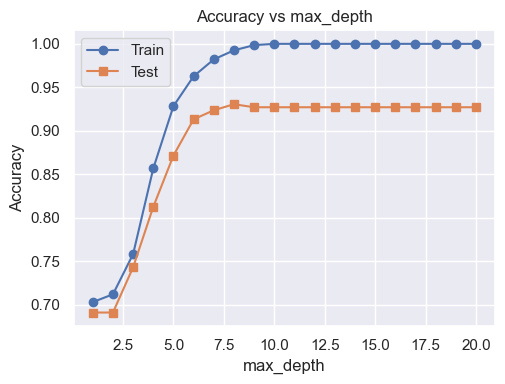

In [24]:
# График зависимости от max_depth
depths = range(1, 21)
train_acc, test_acc = [], []

for d in depths:
    tree = DecisionTree(feature_types=feature_types, max_depth=d)
    tree.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, tree.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, tree.predict(X_te)))

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(depths, train_acc, label='Train', marker='o')
plt.plot(depths, test_acc, label='Test', marker='s')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs max_depth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()  

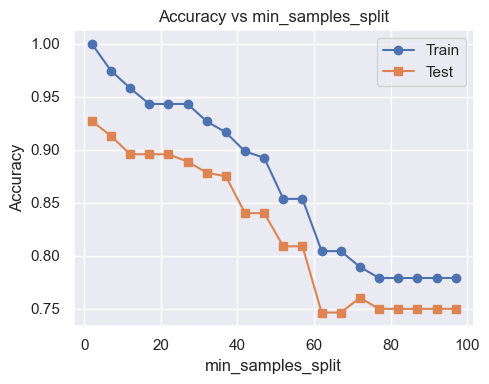

In [25]:
# График зависимости от min_samples_split
splits = range(2, 101, 5)
train_acc, test_acc = [], []

for s in splits:
    tree = DecisionTree(feature_types=feature_types, min_samples_split=s)
    tree.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, tree.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, tree.predict(X_te)))

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 2)
plt.plot(splits, train_acc, label='Train', marker='o')
plt.plot(splits, test_acc, label='Test', marker='s')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.title('Accuracy vs min_samples_split')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

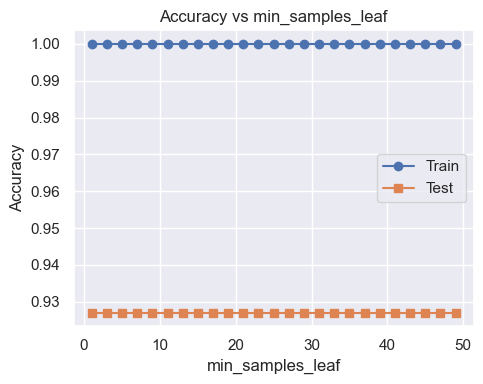

In [26]:
# График зависимости от min_samples_leaf
leafs = range(1, 51, 2)
train_acc, test_acc = [], []

for l in leafs:
    tree = DecisionTree(feature_types=feature_types, min_samples_leaf=l)
    tree.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, tree.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, tree.predict(X_te)))

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 3)
plt.plot(leafs, train_acc, label='Train', marker='o')
plt.plot(leafs, test_acc, label='Test', marker='s')
plt.xlabel('min_samples_leaf')
plt.ylabel('Accuracy')
plt.title('Accuracy vs min_samples_leaf')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.preprocessing import OneHotEncoder
import importlib
import hw2code
importlib.reload(hw2code)
from hw2code import DecisionTree

# 1. Mushrooms
df_mush = pd.read_csv("datasets/agaricus-lepiota.data", header=None, sep=',')
y_mush = LabelEncoder().fit_transform(df_mush.iloc[:, 0].values)
X_mush = df_mush.iloc[:, 1:].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
X_mush = X_mush.values.astype(int)

# 2. Tic-tac-toe
df_ttt = pd.read_csv("datasets/tic-tac-toe-endgame.csv")
y_ttt = LabelEncoder().fit_transform(df_ttt.iloc[:, -1].values)
X_ttt = df_ttt.iloc[:, :-1].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
X_ttt = X_ttt.values.astype(int)

# 3. Cars
df_cars = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data", 
                      header=None)
# класс: unacc, acc = 0; good, vgood = 1
y_cars_raw = df_cars.iloc[:, -1].values
y_cars = np.array([0 if y in ['unacc', 'acc'] else 1 for y in y_cars_raw])
X_cars = df_cars.iloc[:, :-1].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
X_cars = X_cars.values.astype(int)

# 4. Nursery
df_nurs = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data",
                      header=None)

y_nurs_raw = df_nurs.iloc[:, -1].values
y_nurs = np.array([0 if y in ['not_recom', 'recommend'] else 1 for y in y_nurs_raw])
X_nurs = df_nurs.iloc[:, :-1].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
X_nurs = X_nurs.values.astype(int)

datasets_dict = {
    'mushrooms': (X_mush, y_mush),
    'tic-tac-toe': (X_ttt, y_ttt),
    'cars': (X_cars, y_cars),
    'nursery': (X_nurs, y_nurs)
}

scorer = make_scorer(accuracy_score)
results = {}

for name, (X, y) in datasets_dict.items():
    print(f"Processing {name}...")
    
    n_features = X.shape[1]
    
    # 1. DecisionTree (real)
    tree_real = DecisionTree(feature_types=['real'] * n_features)
    scores_real = cross_val_score(tree_real, X, y, cv=10, scoring=scorer)
    
    # 2. DecisionTree (categorical)
    tree_cat = DecisionTree(feature_types=['categorical'] * n_features)
    scores_cat = cross_val_score(tree_cat, X, y, cv=10, scoring=scorer)
    
    # 3. DecisionTree (real) + OneHotEncoder
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_ohe = ohe.fit_transform(X)
    tree_ohe = DecisionTree(feature_types=['real'] * X_ohe.shape[1])
    scores_ohe = cross_val_score(tree_ohe, X_ohe, y, cv=10, scoring=scorer)
    
    # 4. sklearn DecisionTreeClassifier
    clf_sklearn = DecisionTreeClassifier(random_state=42)
    scores_sklearn = cross_val_score(clf_sklearn, X, y, cv=10, scoring=scorer)
    
    results[name] = {
        'DT (real)': scores_real.mean(),
        'DT (categorical)': scores_cat.mean(),
        'DT (real + OHE)': scores_ohe.mean(),
        'sklearn DT': scores_sklearn.mean()
    }

results_df = pd.DataFrame(results).T
print("\n=== Results ===")
print(results_df)

Processing mushrooms...
Processing tic-tac-toe...
Processing cars...
Processing nursery...

=== Results ===
             DT (real)  DT (categorical)  DT (real + OHE)  sklearn DT
mushrooms     0.999261          1.000000         0.999631    0.960384
tic-tac-toe   0.467533          0.541458         0.543575    0.771678
cars          0.942647          0.967546         0.919495    0.942707
nursery       0.999691          0.999846         0.999537    0.999691


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**
**Анализ результатов:**

*   **Mushrooms**: Лучший результат (1.0) достигнут при обработке признаков как категориальных (`DT categorical`). Это ожидаемо, так как природа данных категориальная, и использованный метод Target Encoding эффективно находит оптимальные разбиения. Трактовка признаков как вещественных (`DT real`) снижает качество, так как навязывает данным несуществующий порядок.
*   **Tic-tac-toe**: Реализация `sklearn` значительно превосходит остальные методы (~0.77 против ~0.54). Вероятно, это связано с тем, что в данном датасете важны сложные взаимодействия признаков, которые плохо улавливаются жадным алгоритмом с Target Encoding. Sklearn строит более эффективные деревья для таких зависимостей.
*   **Cars**: Лидирует подход `DT (categorical)`. Использование One-Hot Encoding (`DT real + OHE`) показало худший результат, что объясняется избыточным увеличением размерности признакового пространства и возможным переобучением.
*   **Nursery**: Все алгоритмы показали высокую точность (~0.999), что говорит о простой разделяющей поверхности и четкой зависимости целевой переменной от признаков.

**Влияние случайности:**

Результаты зависят от случайного разбиения выборки при кросс-валидации и порядка выбора признаков при одинаковых значениях критерия информативности. Для повышения устойчивости оценок можно усреднять результаты нескольких запусков с различными `random_state` и проводить подбор гиперпараметров регуляризации.


Вставьте что угодно, описывающее ваши впечатления от этого задания: